
| <h1> **Hands-on Activity 9.2** </h1> | <h1> **Customized Visualizations using Seaborn** </h1> |
|--- | --- |
Name: | Rubang, Jethro Aaron S.<br>
Course and Section: |  CPE 311-CPE22S3<br>
Instructor: | Eng. Neal Barton James Matira
Date Performed: | March 9, 2026
Date Submitted: | March 9, 2026


<hr>


# Introduction to Seaborn

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
fb = pd.read_csv(
'fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
quakes = pd.read_csv('earthquakes-1.csv')

In [13]:
quakes.assign(
    time=lambda x: pd.to_datetime(x.time, unit='ms')
).set_index('time').loc['2018-09-28'].query(
    "parsed_place == 'Indonesia' and tsunami == 1 and mag == 7.5"
)

,mag,magType,place,tsunami,parsed_place
time,,,,,
2018-09-28 10:02:43.480,7.5,mww,"78km N of Palu, Indonesia",1,Indonesia


stripplot()

<Axes: xlabel='magType', ylabel='mag'>

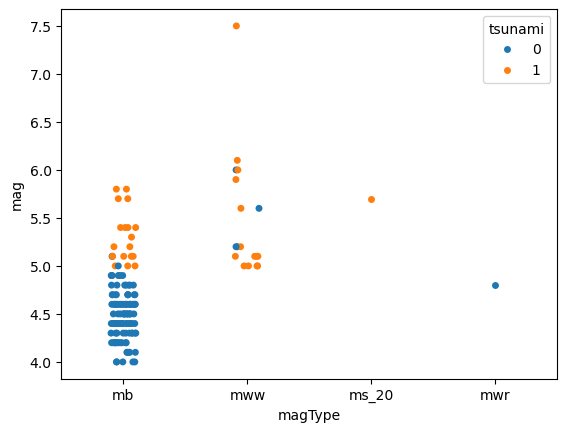

In [14]:
sns.stripplot(
    x='magType',
    y='mag',
    hue='tsunami',
    data=quakes.query('parsed_place == "Indonesia"')
)

The strip plot shows the distribution of the earthquake magnitudes by type of magnitudes. Every point is an earthquake occasion that is recorded. The color suggests the presence of a tsunami or not. It is revealed in the plot that higher magnitude earthquakes tend to be more related to tsunami occurrences although not every high magnitude earthquake results in a tsunami.

swarmplot()

<Axes: xlabel='magType', ylabel='mag'>

c:\Users\jethr\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


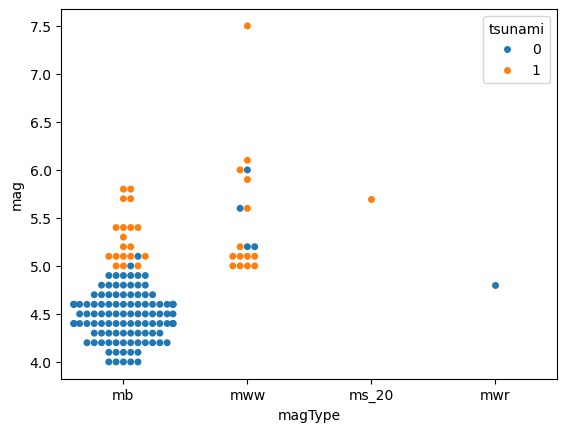

In [15]:
sns.swarmplot(
    x='magType',
    y='mag',
    hue='tsunami',
    data=quakes.query('parsed_place == "Indonesia"')
)

The swarm plot does not overlap and it gives a better visual representation of the concentration of the magnitude of earthquakes per category. It can be easily used to identify clusters of earthquake magnitude as compared to strip plot.


Correlations and Heatmaps
heatmap()

<Axes: >

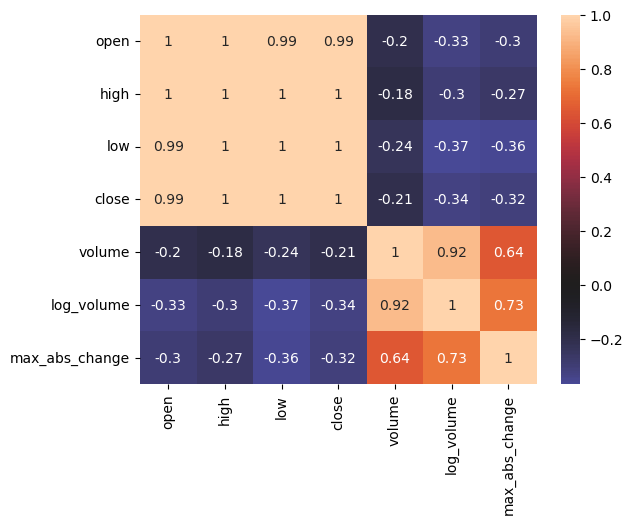

In [16]:
sns.heatmap(
    fb.sort_index().assign(
    log_volume=np.log(fb.volume),
    max_abs_change=fb.high - fb.low
).corr(),
    annot=True, center=0
)

The heatmap indicates the relationship between the variables of Facebook stock. There are strong positive relationships between open, close, high and low prices implying that they move together in the trading periods. Volume and price change has less strength of correlation.

pairplot()

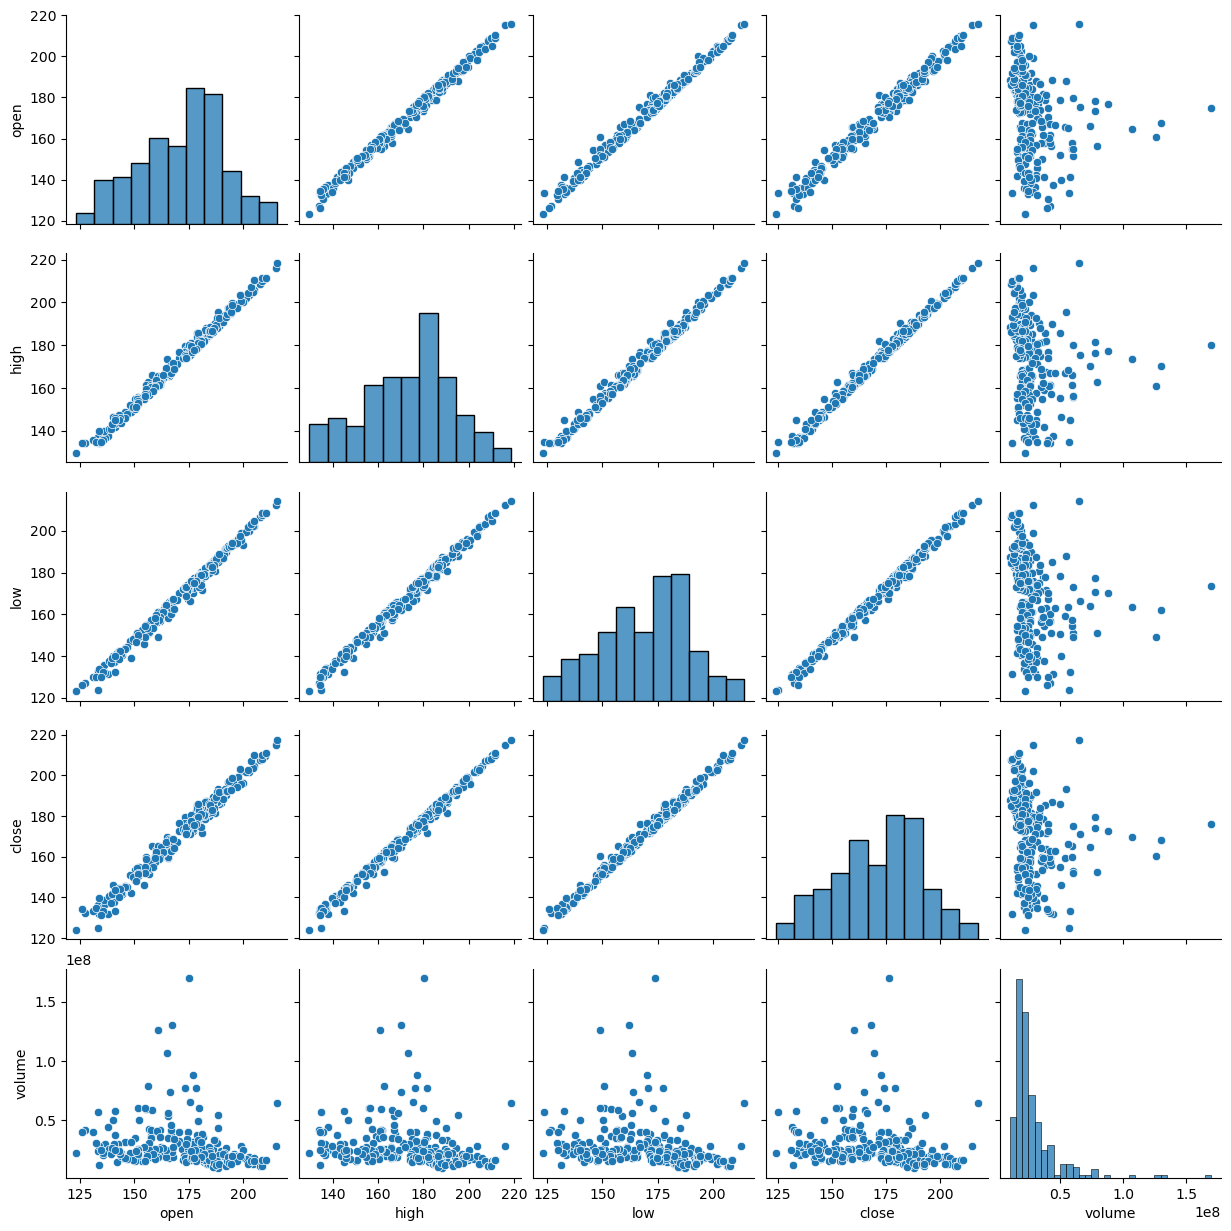

In [17]:
sns.pairplot(fb)

The pairplot represents the relationship between two variables. It enables tracking of tendencies like linear connections between the characteristics of price and the possible outliers.

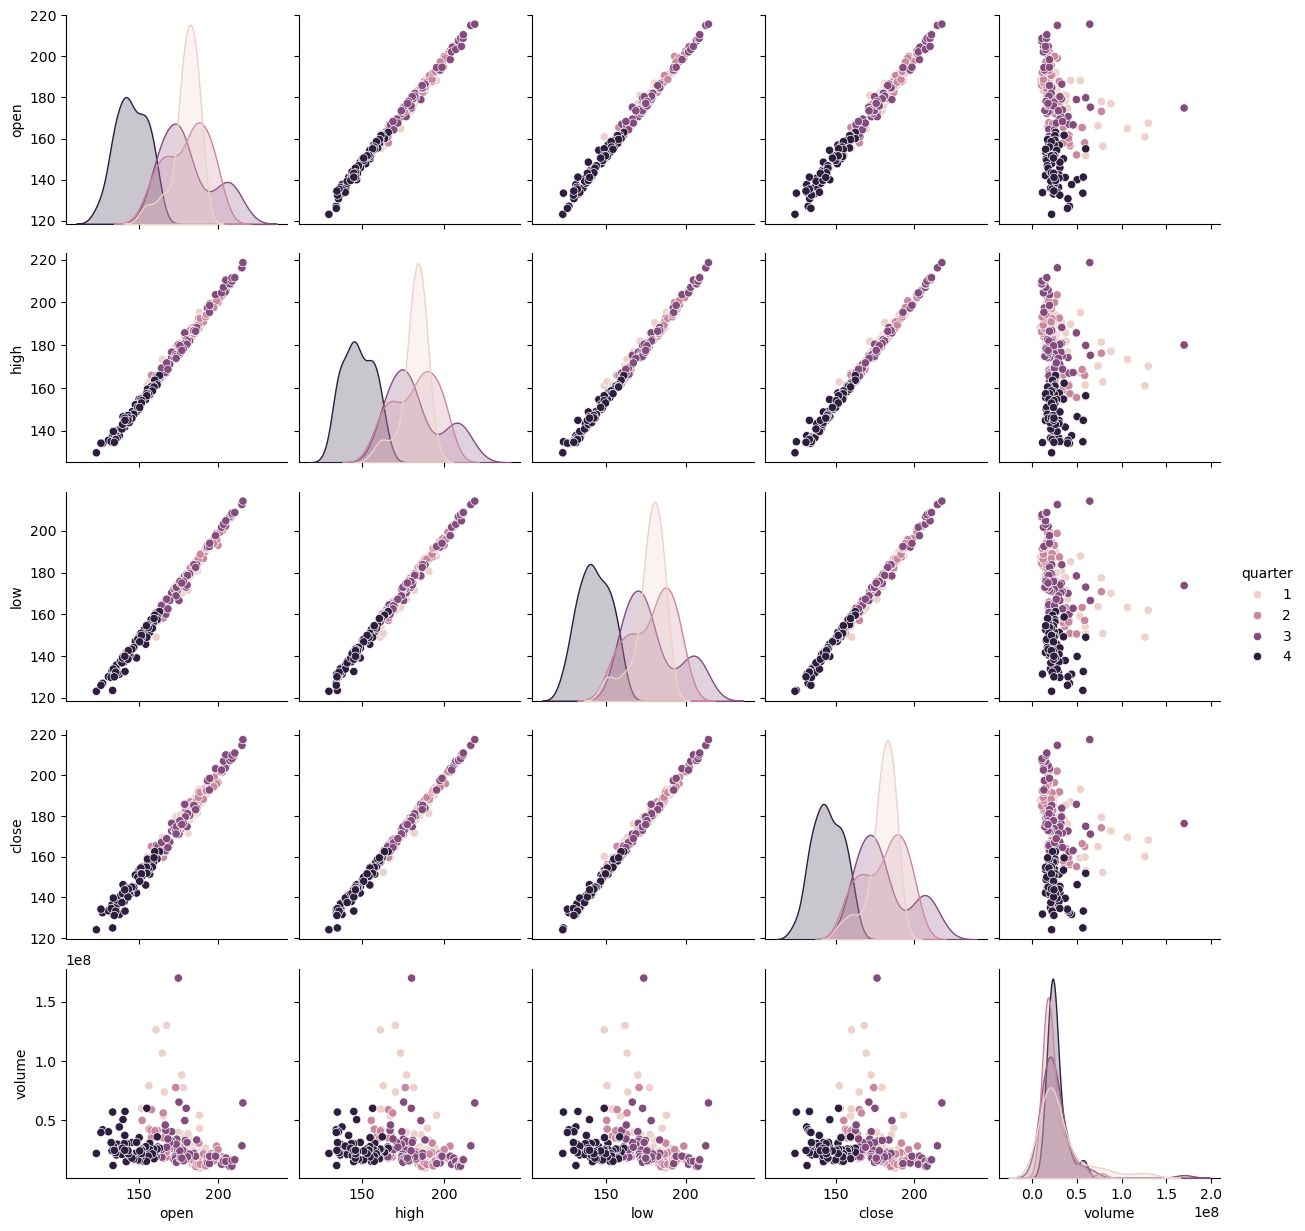

In [18]:
sns.pairplot(
    fb.assign(quarter=lambda x: x.index.quarter),
    diag_kind='kde',
    hue='quarter'
)

This visualization classifies stock data in terms of quarter. The difference between the various quarters is reflected in the scatter plots where the density in the diagonals estimates the distribution of individual variables.


jointplot()

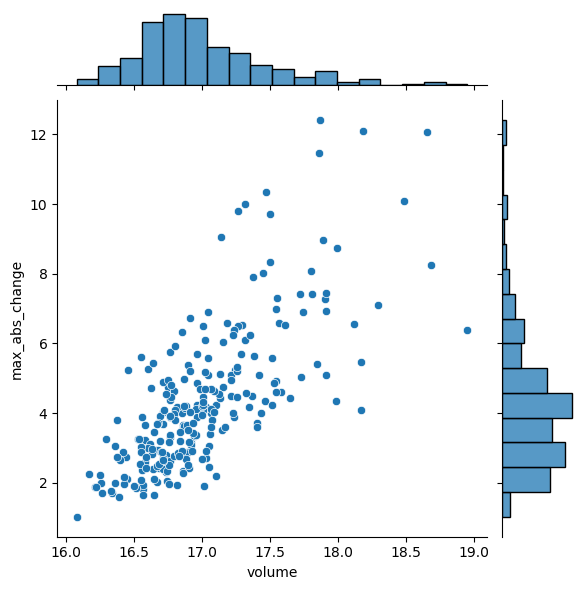

In [19]:
sns.jointplot(
    x='volume',
    y='max_abs_change',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    )
)


The plot in which the relationship between the change in price and the trading volume is depicted is the joint plot. The marginal distributions demonstrate the individual distributions of every variable.

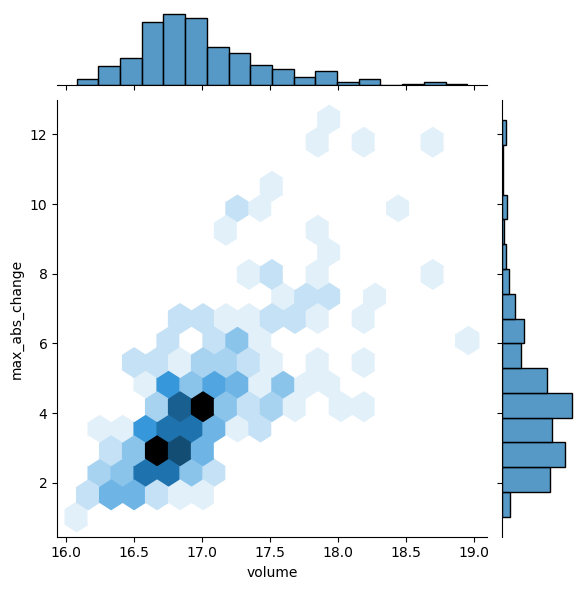

In [20]:
sns.jointplot(
x='volume',
    y='max_abs_change',
    kind='hex',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    )
)

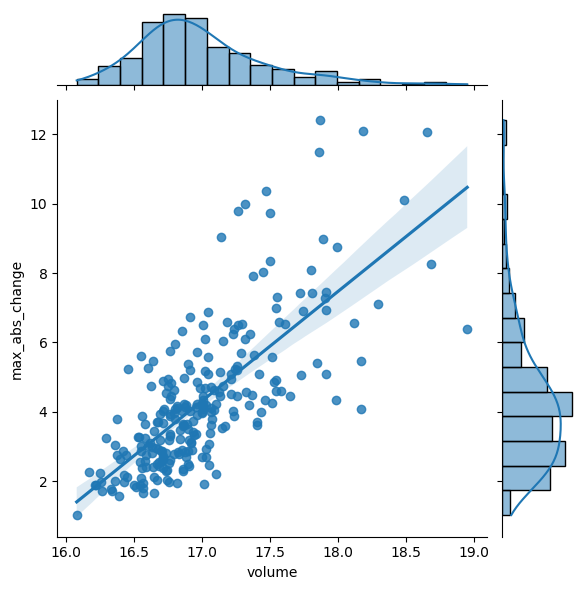

In [21]:
sns.jointplot(
    x='volume',
    y='max_abs_change',
    kind='reg',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    )
)


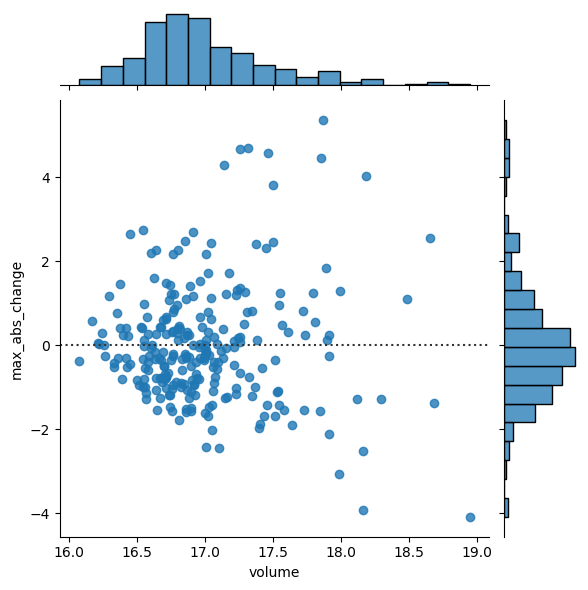

In [22]:
sns.jointplot(
    x='volume',
    y='max_abs_change',
    kind='resid',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    )
)

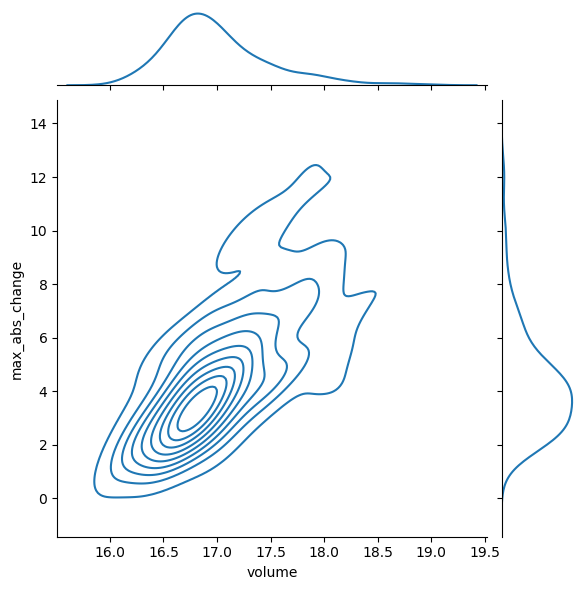

In [23]:
sns.jointplot(
    x='volume',
    y='max_abs_change',
    kind='kde',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
)
)

Regression plots

In [24]:
fb_reg_data = fb.assign(
    volume=np.log(fb.volume),
    max_abs_change=fb.high - fb.low
).iloc[:,-2:]

In [25]:
import itertools

In [26]:
iterator = itertools.repeat("I'm an iterator", 1)
for i in iterator:
    print(f'-->{i}')
print('This printed once because the iterator has been exhausted')
for i in iterator:
    print(f'-->{i}')

-->I'm an iterator
This printed once because the iterator has been exhausted


In [27]:
iterable = list(itertools.repeat("I'm an iterable", 1))
for i in iterable:
    print(f'-->{i}')
print('This prints again because it\'s an iterable:')
for i in iterable:
    print(f'-->{i}')

-->I'm an iterable
This prints again because it's an iterable:
-->I'm an iterable


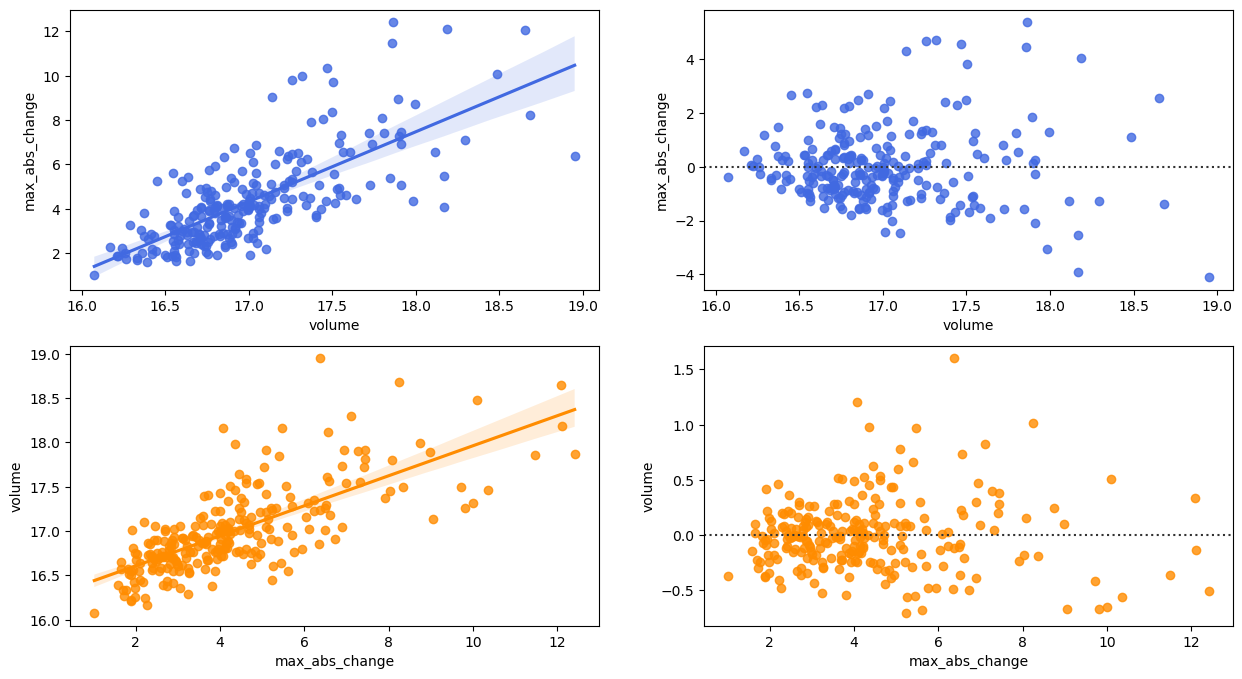

In [28]:
from reg_resid_plot import reg_resid_plots
reg_resid_plots(fb_reg_data)

Regression charts are used to show the linear relationship between the trading volume and the price volatility. The residual plots are used to identify the goodness of fit of the regression model to the data by revealing the deviations of the regression line.

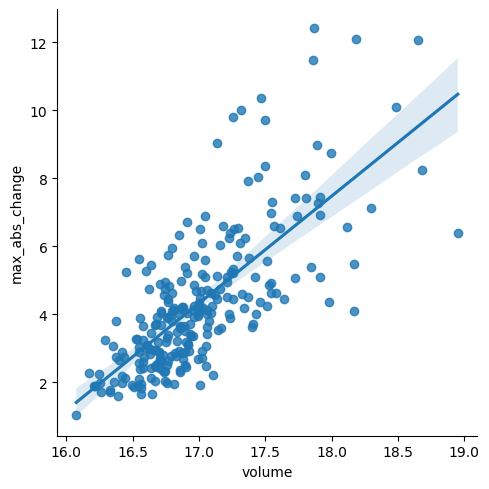

In [30]:
sns.lmplot(
    x='volume',
    y='max_abs_change',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low,
        quarter=lambda x: x.index.quarter
    ),
),
col='quarter'


Text(0.5, 0.98, 'Comparing earthquake magnitude by magType')

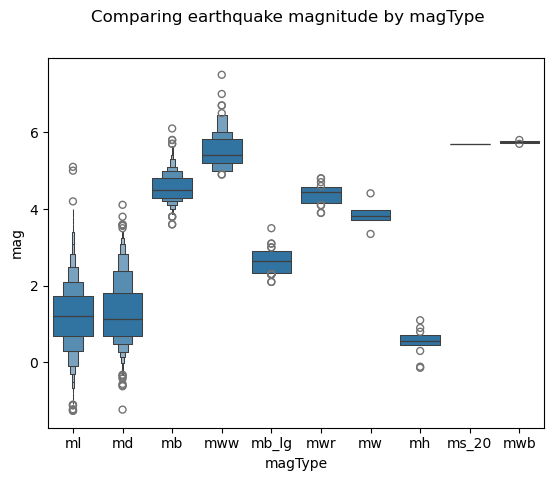

In [31]:
sns.boxenplot(
    x='magType', y='mag', data=quakes[['magType', 'mag']]
)
plt.suptitle('Comparing earthquake magnitude by magType')

C:\Users\jethr\AppData\Local\Temp\ipykernel_29652\603559778.py:2: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


Text(0.5, 0.98, 'Comparing earthquake magnitude by magType')

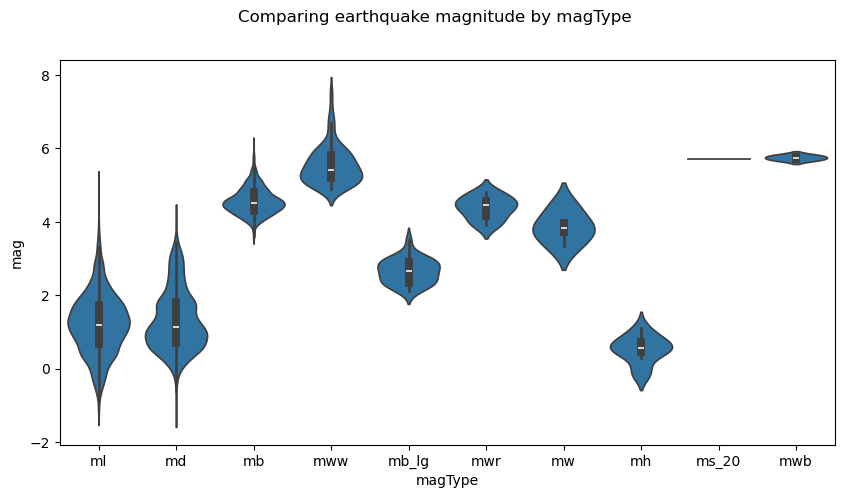

In [32]:
fig, axes = plt.subplots(figsize=(10, 5))
sns.violinplot(
x='magType', y='mag', data=quakes[['magType', 'mag']],
ax=axes, scale='width' # all violins have same width
)
plt.suptitle('Comparing earthquake magnitude by magType')

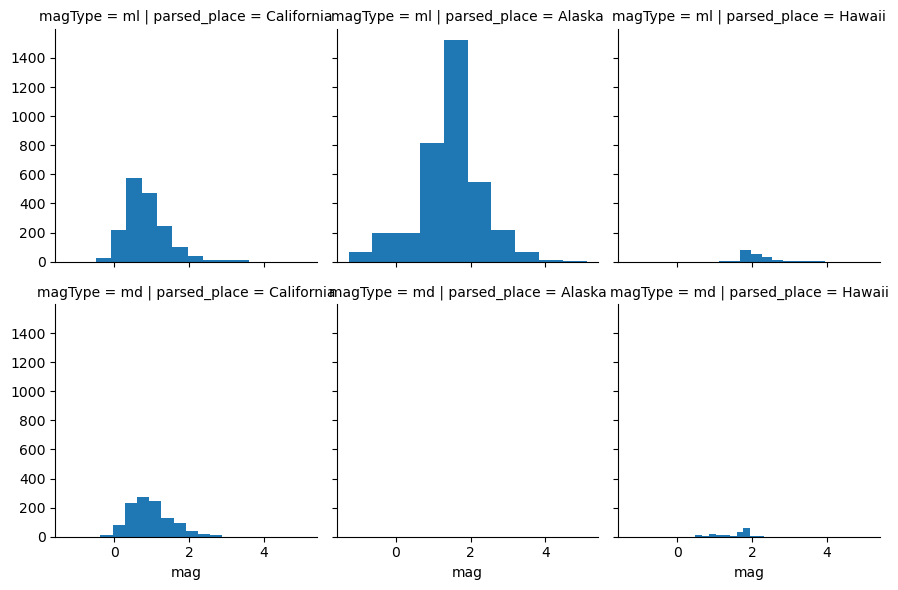

In [33]:
g = sns.FacetGrid(
    quakes[
        (quakes.parsed_place.isin([
            'California', 'Alaska', 'Hawaii'
        ]))\
        & (quakes.magType.isin(['ml', 'md']))
    ],
    row='magType',
    col='parsed_place'
)
g = g.map(plt.hist, 'mag')

# 9.5 Formatting Plots

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
fb = pd.read_csv(
'fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)

Text(0, 0.5, 'price ($)')

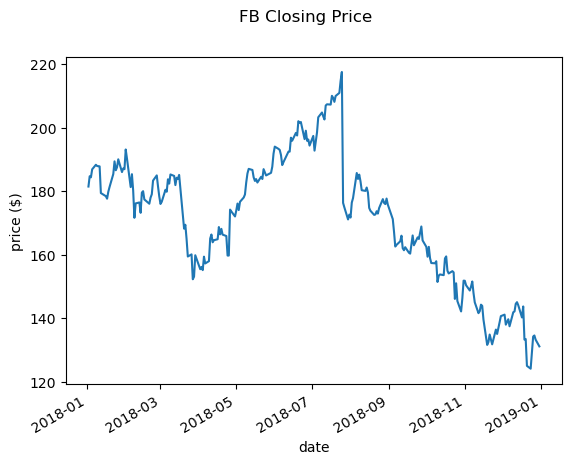

In [35]:
fb.close.plot()
plt.suptitle('FB Closing Price')
plt.xlabel('date')
plt.ylabel('price ($)')

The plot demonstrates the closing price of Facebook stock every day in 2018. It emphasizes trends and volatile seasons of the year.

Text(0, 0.5, 'price ($)')

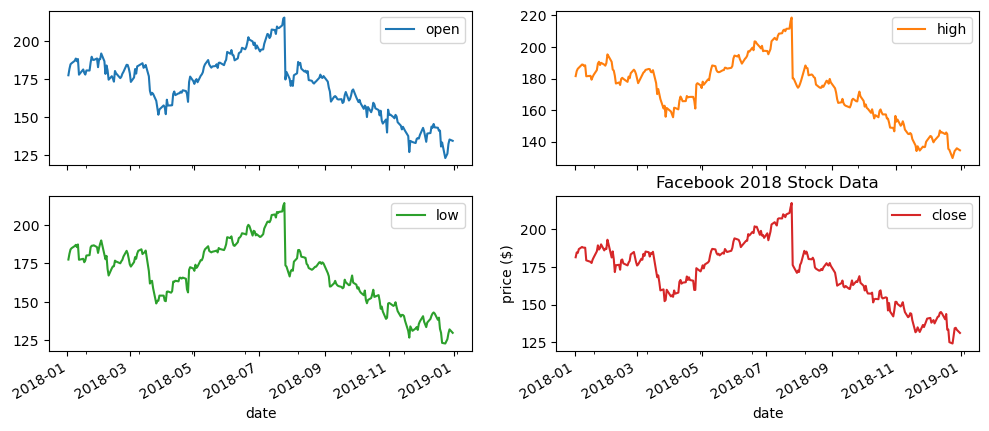

In [36]:
fb.iloc[:,:4].plot(subplots=True, layout=(2, 2), figsize=(12, 5))
plt.title('Facebook 2018 Stock Data')
plt.xlabel('date')
plt.ylabel('price ($)')

Minimizing the time required in subplots of showing numerous variables can be compared in terms of opening price, closing price, high price, and low price. These variables fluctuate in tandem with one another because of the stock trading nature.


Text(0, 0.5, 'price ($)')

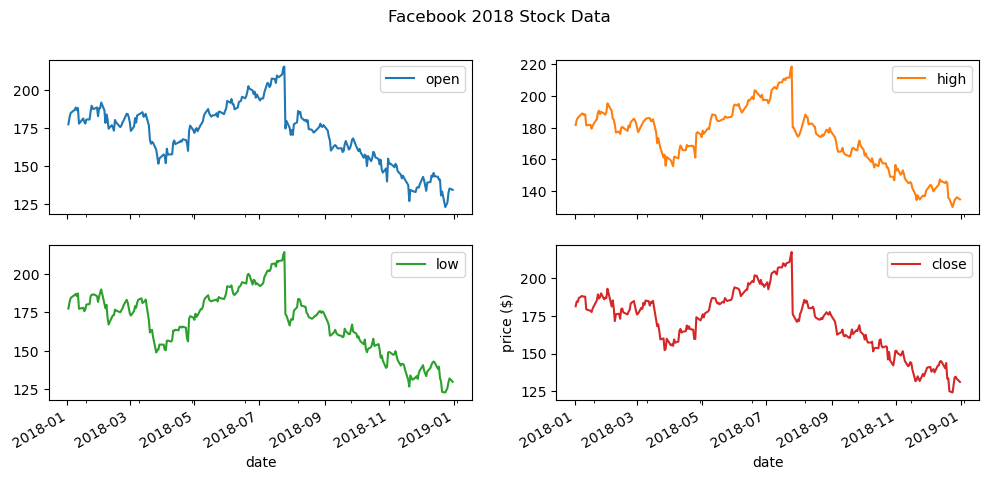

In [37]:
fb.iloc[:,:4].plot(subplots=True, layout=(2, 2), figsize=(12, 5))
plt.suptitle('Facebook 2018 Stock Data')
plt.xlabel('date')
plt.ylabel('price ($)')

Text(0, 0.5, 'price ($)')

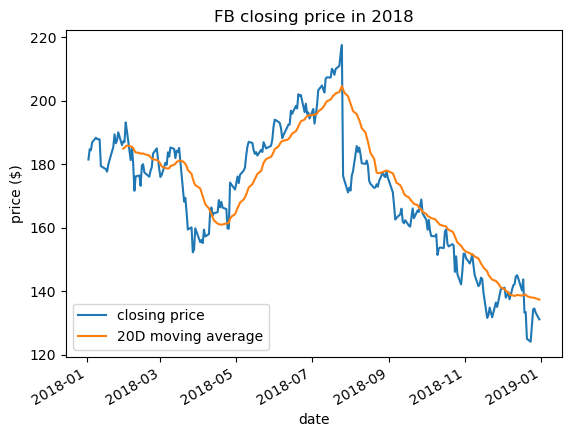

In [38]:
fb.assign(
    ma=lambda x: x.close.rolling(20).mean()
).plot(
    y=['close', 'ma'],
    title='FB closing price in 2018',
    label=['closing price', '20D moving average']
)
plt.legend(loc='lower left')
plt.ylabel('price ($)')

The moving average filters off short term changes and emphasizes the long term trends of the stock price.


Text(0, 0.5, 'price ($)')

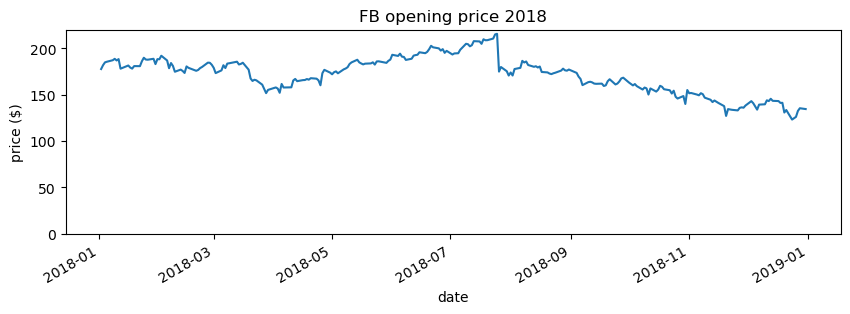

In [39]:
fb.open.plot(figsize=(10, 3), title='FB opening price 2018')
plt.ylim(0, None)
plt.ylabel('price ($)')

ValueError: The number of FixedLocator locations (7), usually from a call to set_ticks, does not match the number of labels (6).

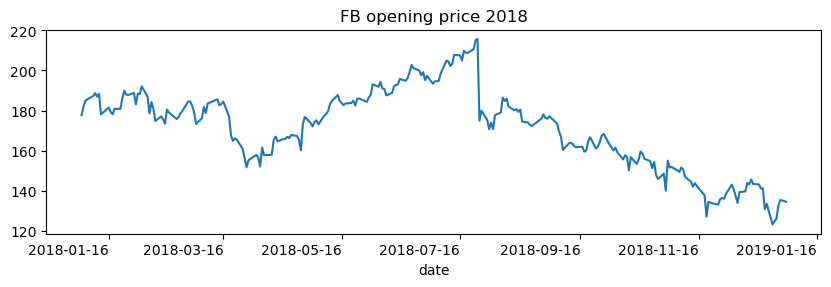

In [40]:
import calendar
fb.open.plot(figsize=(10, 3), rot=0, title='FB opening price 2018')
locs, labels = plt.xticks()
plt.xticks(locs + 15 , calendar.month_name[1::2])
plt.ylabel('price ($)')

Text(0, 0.5, 'percent of highest price ($218.62)')

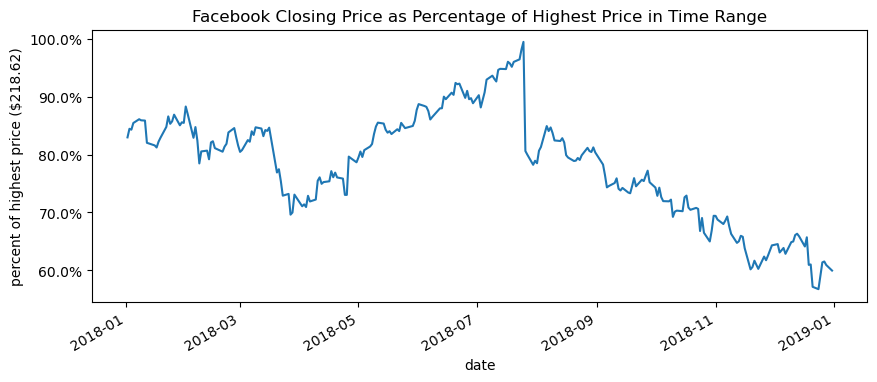

In [41]:
import matplotlib.ticker as ticker

ax = fb.close.plot(
    figsize=(10, 4),
    title='Facebook Closing Price as Percentage of Highest Price in Time Range'
)
ax.yaxis.set_major_formatter(
    ticker.PercentFormatter(xmax=fb.high.max())
)
ax.set_yticks([
    fb.high.max()*pct for pct in np.linspace(0.6, 1, num=5)
]) # show round percentages only (60%, 80%, etc.)
ax.set_ylabel(f'percent of highest price (${fb.high.max()})')

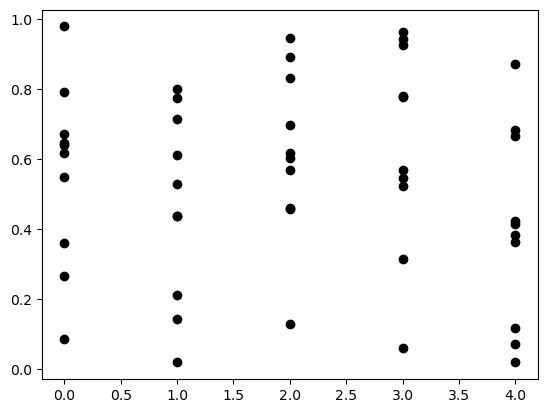

In [42]:
fig, ax = plt.subplots(1, 1)
np.random.seed(0)
ax.plot(np.tile(np.arange(0, 5), 10), np.random.rand(50), 'ko')

# 9.6 Customizing Visualizations

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
fb = pd.read_csv(
'fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)

array([[<Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>,
        <Axes: xlabel='volume', ylabel='open'>],
       [<Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>,
        <Axes: xlabel='volume', ylabel='high'>],
       [<Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>,
        <Axes: xlabel='volume', ylabel='low'>],
       [<Axes: xlabel='open', ylabel='close'>,
        <Axes: xlabel='high', ylabel='close'>,
        <Axes: xlabel='low', ylabel='close'>,
        <Axes: xlabel='close', ylabel='close'>,
        <Axes: xlabel='volume', ylabel='close'>],
       [<Axes: xlabel='open', ylabel='volume'>,
        <Axes: xlabe

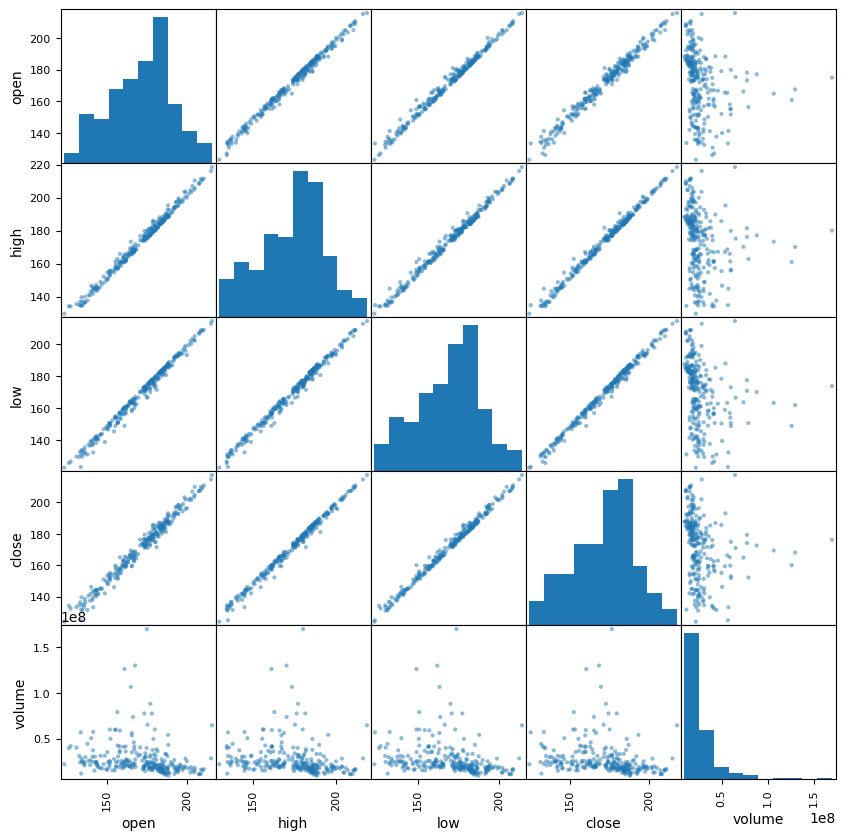

In [45]:
from pandas.plotting import scatter_matrix
scatter_matrix(fb, figsize=(10, 10))

Scatter matrices depict pair wise relationships among all variables at the same time. They can be used to detect correlations and also to identify potential outliers.

array([[<Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>,
        <Axes: xlabel='volume', ylabel='open'>],
       [<Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>,
        <Axes: xlabel='volume', ylabel='high'>],
       [<Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>,
        <Axes: xlabel='volume', ylabel='low'>],
       [<Axes: xlabel='open', ylabel='close'>,
        <Axes: xlabel='high', ylabel='close'>,
        <Axes: xlabel='low', ylabel='close'>,
        <Axes: xlabel='close', ylabel='close'>,
        <Axes: xlabel='volume', ylabel='close'>],
       [<Axes: xlabel='open', ylabel='volume'>,
        <Axes: xlabe

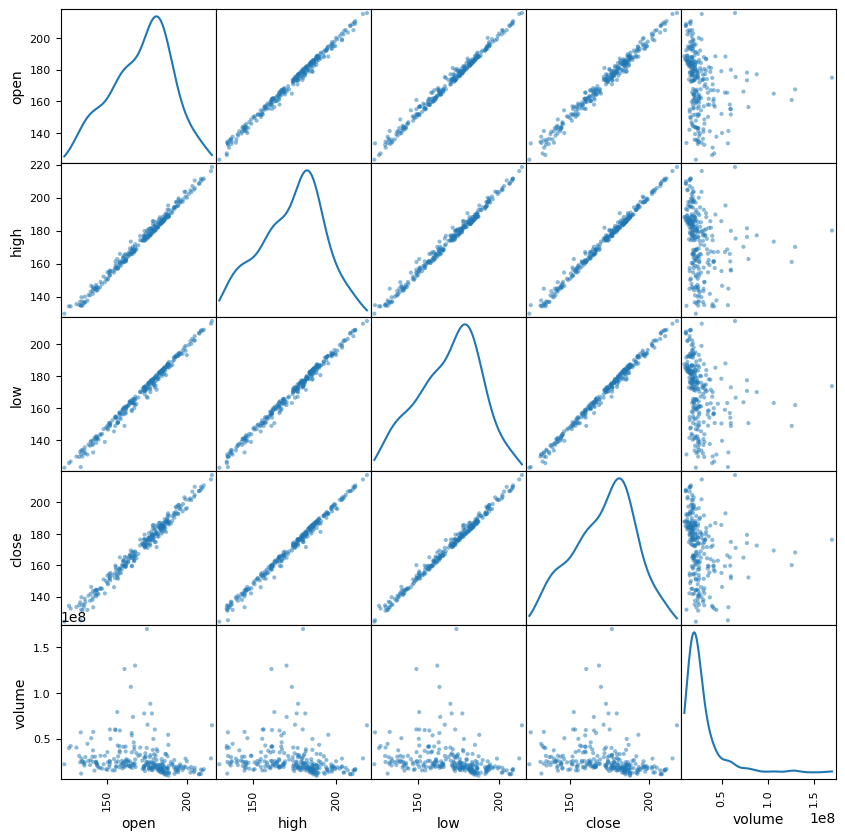

In [46]:
scatter_matrix(fb, figsize=(10, 10), diagonal='kde')

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

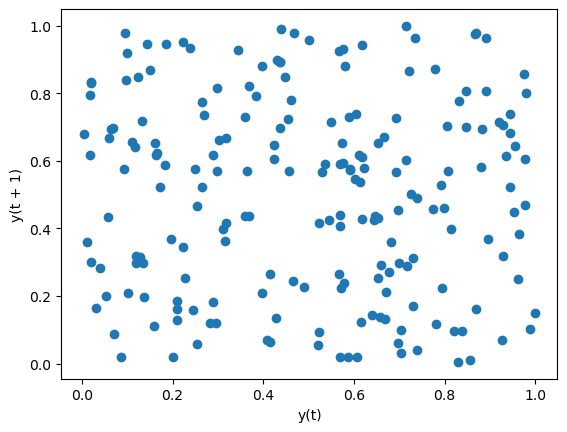

In [47]:
from pandas.plotting import lag_plot
np.random.seed(0) # make this repeatable
lag_plot(pd.Series(np.random.random(size=200)))

The lag plot tests autocorrelation of the time series. An observable trend denotes a dependence of present and past values.

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

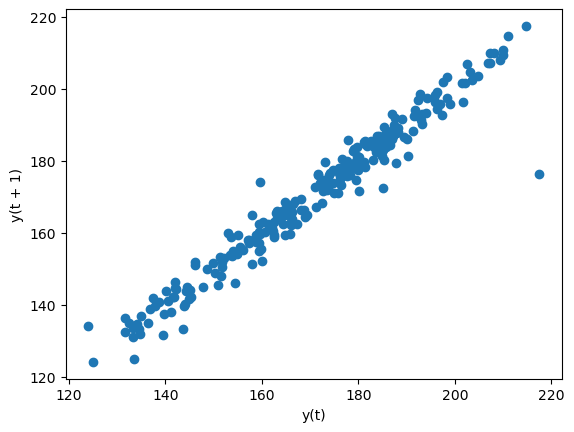

In [48]:
lag_plot(fb.close)

<Axes: xlabel='y(t)', ylabel='y(t + 5)'>

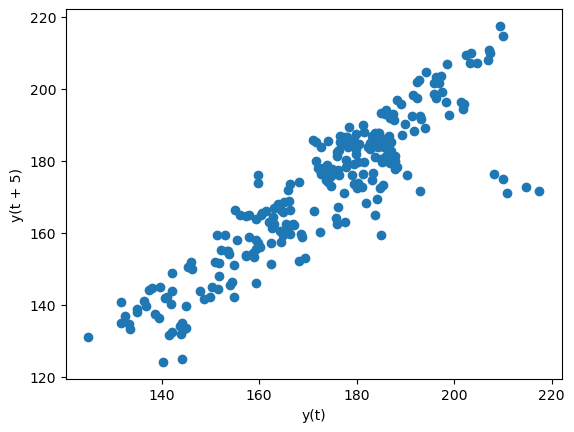

In [49]:
lag_plot(fb.close, lag=5)

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

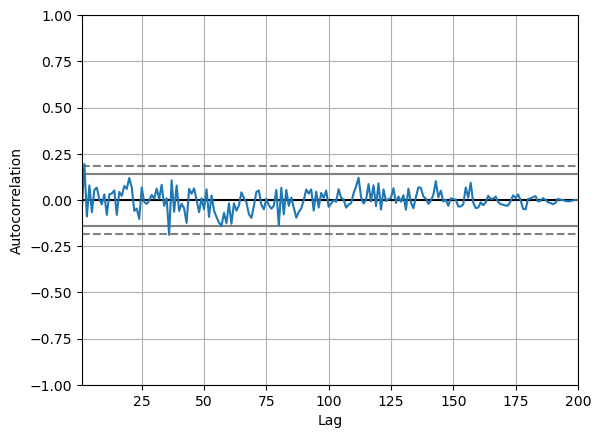

In [50]:
from pandas.plotting import autocorrelation_plot
np.random.seed(0) # make this repeatable
autocorrelation_plot(pd.Series(np.random.random(size=200)))

The autocorrelation plot is used to measure the correlation between the series and lagged versions of the same series. Significant spikes would point towards predictable patterns in the time series.


<Axes: xlabel='Lag', ylabel='Autocorrelation'>

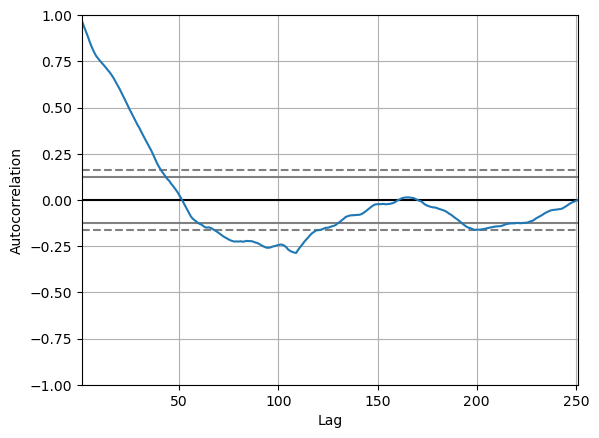

In [51]:
autocorrelation_plot(fb.close)

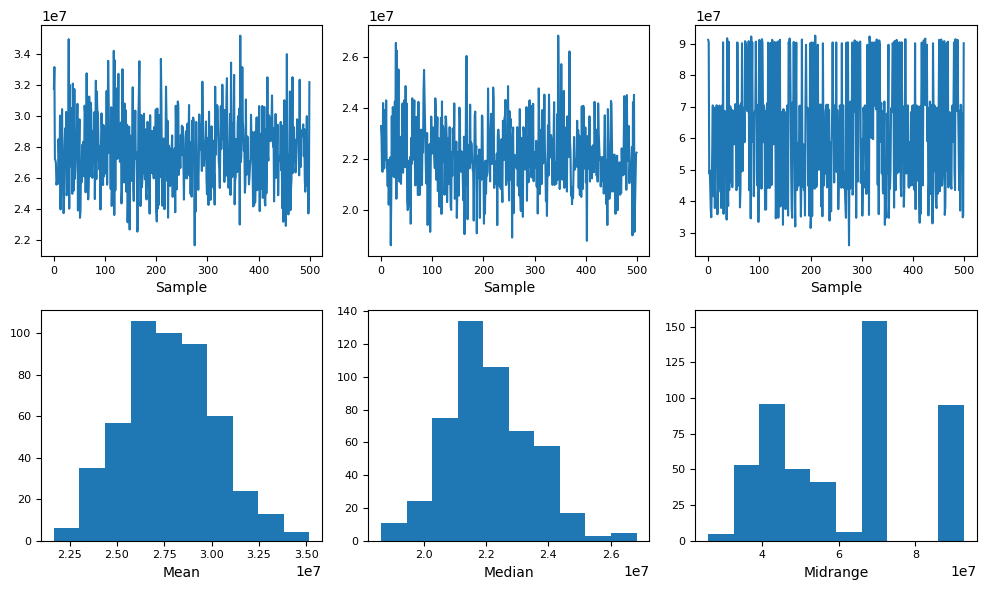

In [53]:
from pandas.plotting import bootstrap_plot
fig = bootstrap_plot(fb.volume, fig=plt.figure(figsize=(10, 6)))

# Supplementary Activity

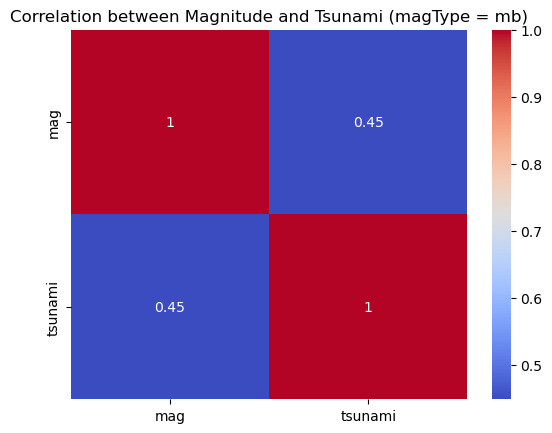

In [54]:
quake_mb = quakes[quakes['magType'] == 'mb']

sns.heatmap(
    quake_mb[['mag','tsunami']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation between Magnitude and Tsunami (magType = mb)")
plt.show()

The heat map illustrates how earthquake magnitude and tsunami event are related to the occurrence of mb-type earthquakes. A positive correlation shows that the bigger the magnitude the higher the chances of occurrence of tsunamis.

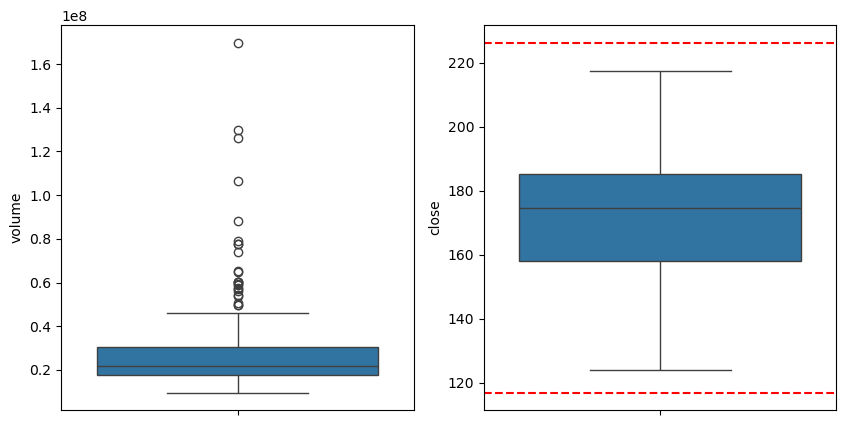

In [55]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

sns.boxplot(y=fb.volume, ax=ax[0])
sns.boxplot(y=fb.close, ax=ax[1])

Q1 = fb.close.quantile(0.25)
Q3 = fb.close.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

ax[1].axhline(lower, color='red', linestyle='--')
ax[1].axhline(upper, color='red', linestyle='--')

The Tukey fence will assist in determining the possible outliers in the data. Values outside of these ranges will be deemed as statistically abnormal.


In [56]:
ax[1].fill_between(
    range(len(fb.close)),
    lower,
    upper,
    color='gray',
    alpha=0.2
)

Text(0.5, 1.0, 'Facebook Closing Price with Highlighted Drop')

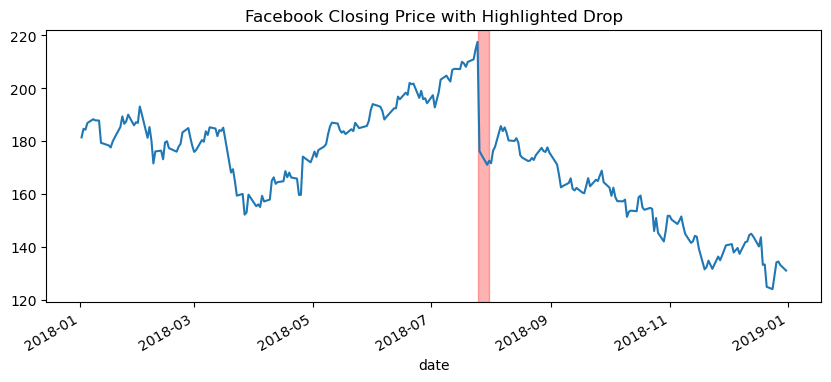

In [57]:
fig, ax = plt.subplots(figsize=(10,4))

fb.close.plot(ax=ax)

ax.axvspan('2018-07-25','2018-07-31', color='red', alpha=0.3)

plt.title("Facebook Closing Price with Highlighted Drop")

Text(2018-02-01, 200, 'FTC investigation')

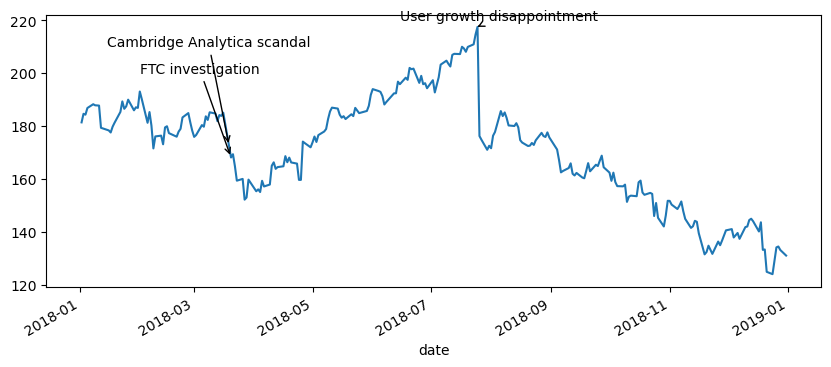

In [58]:
fig, ax = plt.subplots(figsize=(10,4))
fb.close.plot(ax=ax)

ax.annotate(
    "User growth disappointment",
    xy=('2018-07-25', fb.loc['2018-07-25','close']),
    xytext=('2018-06-15',220),
    arrowprops=dict(arrowstyle="->")
)

ax.annotate(
    "Cambridge Analytica scandal",
    xy=('2018-03-19', fb.loc['2018-03-19','close']),
    xytext=('2018-01-15',210),
    arrowprops=dict(arrowstyle="->")
)

ax.annotate(
    "FTC investigation",
    xy=('2018-03-20', fb.loc['2018-03-20','close']),
    xytext=('2018-02-01',200),
    arrowprops=dict(arrowstyle="->")
)

The stippled area demonstrates that the share price in Facebook significantly reduces within the given time.

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def reg_resid_plots(data):

    cmap = plt.cm.Set2
    colors = cmap(np.linspace(0,1,len(data.columns)))

    fig, axes = plt.subplots(len(data.columns),2, figsize=(10,6))

    for i, col in enumerate(data.columns):

        sns.regplot(
            x=data.index,
            y=data[col],
            ax=axes[i,0],
            color=colors[i]
        )

        sns.residplot(
            x=data.index,
            y=data[col],
            ax=axes[i,1],
            color=colors[i]
        )

    plt.tight_layout()

In this alteration, a qualitative matplotlib colormap is used in place of alternating between two fixed colors.

# Conclusion

This activity has also shown that Seaborn and Matplotlib could be utilized to analyze and discuss exploratory data in an engaging way and develop valuable visualizations. There are various forms of plots including strip plots, swarm plots, heatmaps, pair plots, and joint plots that are used to show relationships and trends within datasets. Time-series data can be read and interpreted better with various techniques that use annotations, colored areas, and moving averages to enhance the data. Visualizations can be customized and other statistical measures such as Tukey fences are used to identify outliers and significant occurrences in the data. In general, the exercise demonstrated the ability of effective data visualization to aid a better comprehension of data trends, correlation, and anomalies in real-world data, including records of earthquakes and Facebook stock prices.